In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
dataset = pd.read_csv('data/titanic-dataset.csv')

- passengerid: id del pasajero (no importante)
- survived: 
  - 0 = No sobrevivió
  - 1 = Sobrevivió
- pclass = clase del pasajero (importante)
  - 1 = Primera clase
  - 2 = Segunda clase
  - 3 = Tercera clase
- name = nombre del pasajero (no importante)
- sex = sexo del pasajero (male, female) (importante)
- age = edad del pasajero (importante)
- sibsp = número de hermanos o cónyuges a bordo (importante)
- parch = número de padres o hijos a bordo (importante)
- ticket = número de ticket (no importante)
- fare = tarifa pagada (importante)
- cabin = número de cabin (no importante)
- embarked = puerto de embarque (importante)
  - C = Cherbourg
  - Q = Queenstown
  - S = Southampton

el dataset muestra que:
- las personas de entre 15 y 30 años tuvieron una tasa de supervivencia más baja que las personas mayores de 30 y menores de 15 años. Las edades mas bajas tuvieron una tasa de supervivencia mucho mas alta
- las pesonas de clase 1 tuvieron la tasa de supervivencia mas alta, mientras que la clase 3 tuvo la mas baja
- las personas que viajaban solas tuvieron una tasa de supervivencia mas baja que las personas que viajaban con familiares
- las mujeres tuvieron una tasa de supervivencia mas alta que los hombres
- las personas que pagaron tarifas mas altas tuvieron una tasa de supervivencia mas alta que las personas que pagaron tarifas mas bajas
- las personas que viajaban desde el puerto "S" tuvieron la tasa de supervivencia mas baja. luego le sigue la "Q" y la "C" con la tasa de supervivencia mas alta

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
dataset = dataset.rename(columns = {
  col: col.lower().replace(' ', '_') for col in dataset.columns
})

In [6]:
for col in dataset.columns:
  print(f"{col}: {dataset[col].nunique()} unique values")

passengerid: 891 unique values
survived: 2 unique values
pclass: 3 unique values
name: 891 unique values
sex: 2 unique values
age: 88 unique values
sibsp: 7 unique values
parch: 7 unique values
ticket: 681 unique values
fare: 248 unique values
cabin: 147 unique values
embarked: 3 unique values


In [7]:
dataset.groupby("sex")["sex"].value_counts()

sex
female    314
male      577
Name: count, dtype: int64

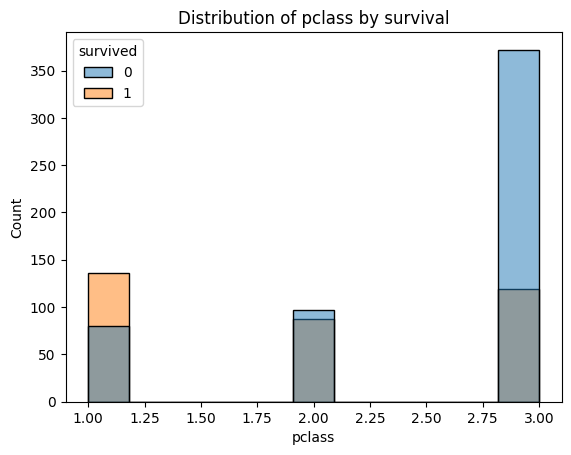

<Figure size 1500x1000 with 0 Axes>

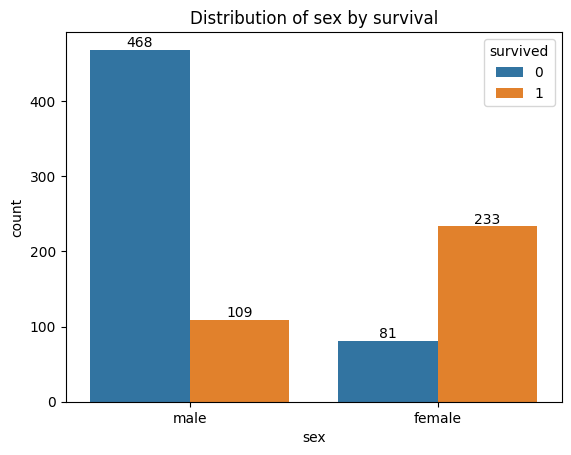

<Figure size 1500x1000 with 0 Axes>

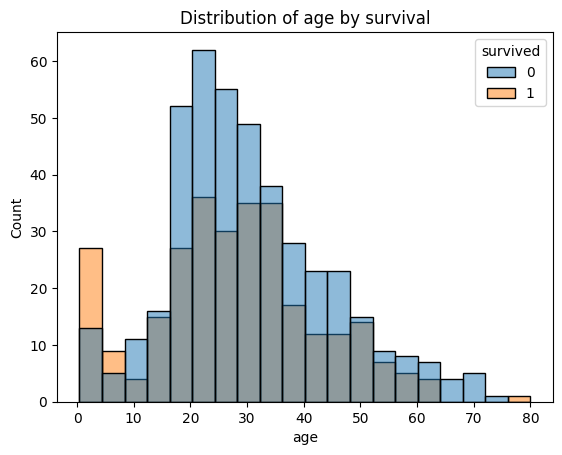

<Figure size 1500x1000 with 0 Axes>

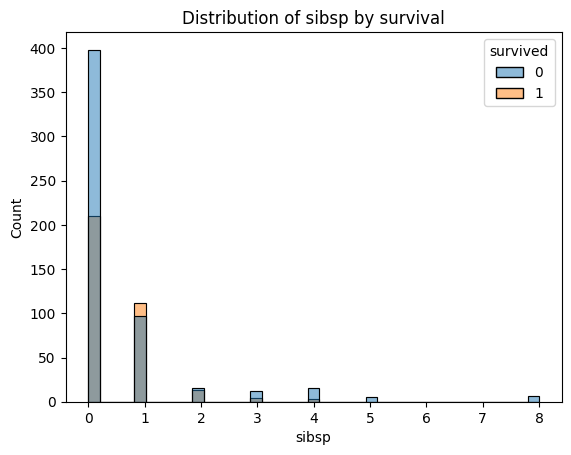

<Figure size 1500x1000 with 0 Axes>

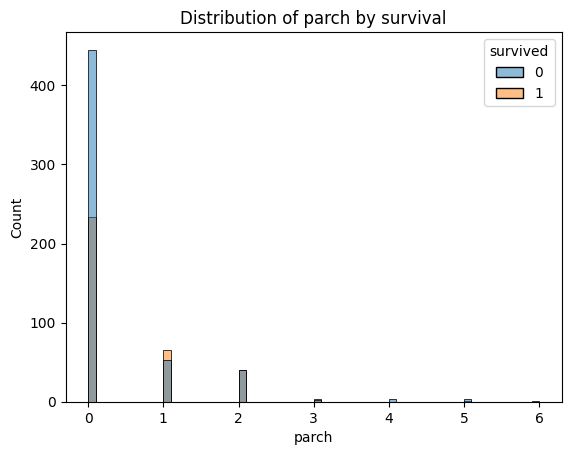

<Figure size 1500x1000 with 0 Axes>

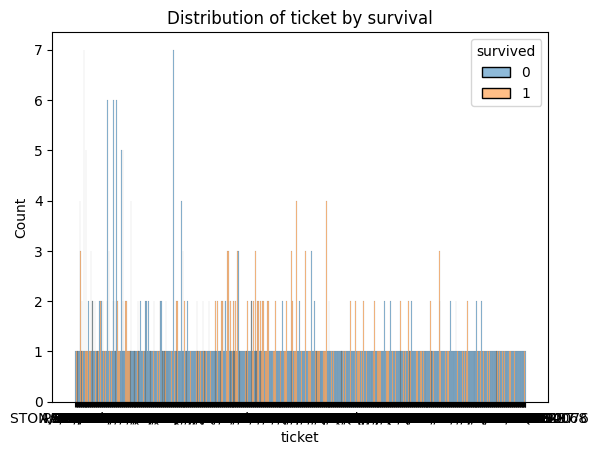

<Figure size 1500x1000 with 0 Axes>

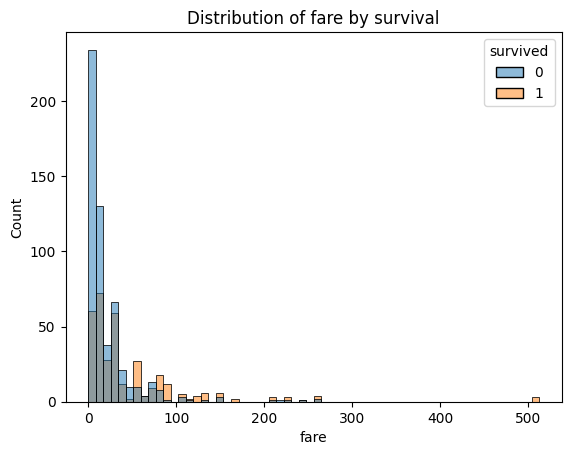

<Figure size 1500x1000 with 0 Axes>

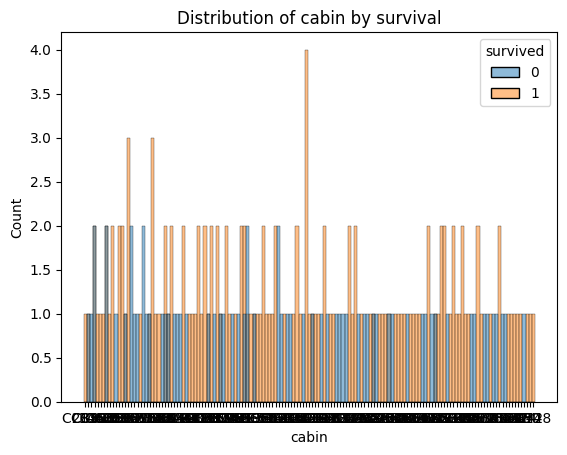

<Figure size 1500x1000 with 0 Axes>

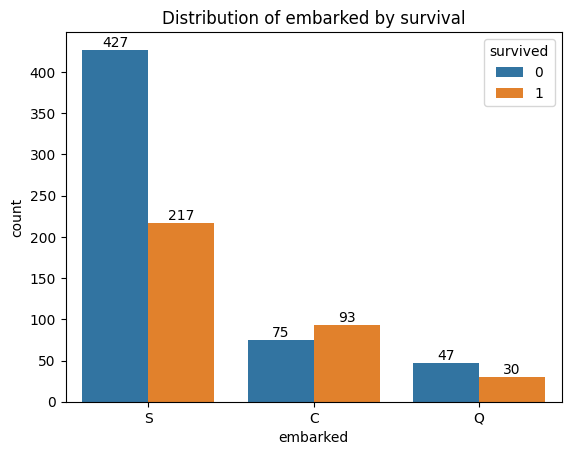

<Figure size 1500x1000 with 0 Axes>

In [8]:
for col in dataset.columns:
  if col == 'survived' or col == "passengerid" or col == "name": continue
  if dataset[col].dtype == 'object' and dataset[col].nunique() < 10:
    plt.title(f"Distribution of {col} by survival")
    ax = sns.countplot(data=dataset, x=col, hue="survived")
    for container in ax.containers:
      ax.bar_label(container)
  else:
    plt.title(f"Distribution of {col} by survival")
    sns.histplot(data=dataset, x=col, hue="survived")
  plt.figure(figsize=(15, 10))
  plt.show()

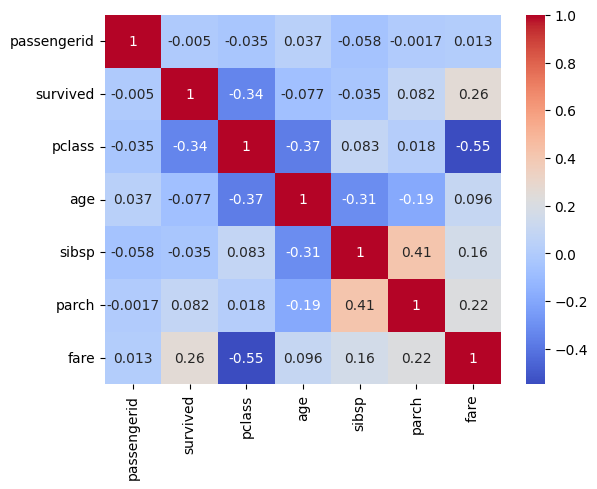

<Figure size 1500x1000 with 0 Axes>

In [9]:
numeric_cols = dataset.select_dtypes(include=np.number).columns
sns.heatmap(dataset[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.figure(figsize=(15, 10))
plt.show()

In [10]:
columns_to_drop = ["passengerid", "name", "ticket", "cabin"]
dataset = dataset.drop(columns=columns_to_drop)

In [11]:
dataset = dataset.dropna(subset=["embarked"]).reset_index(drop=True)

In [12]:
dataset.to_csv("data/cleaned-titanic-dataset.csv", index=False)